In [1]:
import numpy as np
import uproot


def get_centroid_array(
    file_numbers, obj_name="ADC_HIGH_7", base_path="slitA-004-{:03d}.root"
):
    """slitB0-[001].root から指定した番号順に重心の数列（NumPy配列）を返します。

    Parameters:
    -----------
    file_numbers : list or iterable
        取得したいファイル番号のリスト（例: range(0, 10)）
    obj_name : str, default "ADC_HIGH_7"
        読み出すヒストグdラム名
    base_path : str
        ファイル名のパターン（{:03d} は3桁ゼロパディング）

    Returns:
    --------
    np.ndarray
        重心（Mean）が順番に格納された1次元NumPy配列
    """
    centroids = []

    for n in file_numbers:
        file_name = base_path.format(n)

        try:
            with uproot.open(file_name) as f:
                hist = f[obj_name]
                values = hist.values()
                x_edges = hist.axes[0].edges()

            x_centers = (x_edges[:-1] + x_edges[1:]) / 2.0
            total_counts = np.sum(values)

            if total_counts > 0:
                mean = np.sum(x_centers * values) / total_counts
            else:
                mean = np.nan

            centroids.append(mean)

        except Exception:
            # ファイルが存在しない・読み込めない場合は nan を追加
            centroids.append(np.nan)

    return np.array(centroids)

min no 44 ,ave 821.1804
max no 24 ,ave 822.9482
120


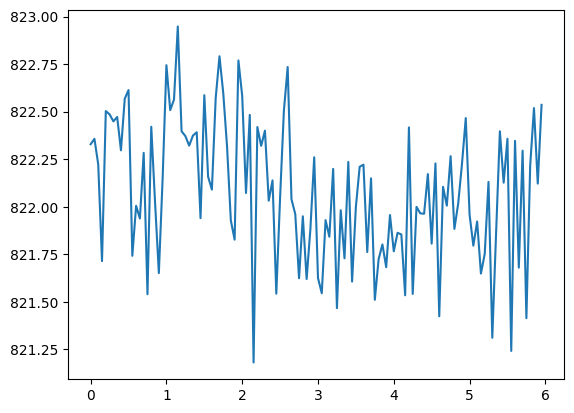

In [47]:
import matplotlib.pyplot as plt
import numpy as np

file_numbers = range(1, 121)
sama = get_centroid_array(file_numbers)
x = np.arange(0, 6.00, 0.05)

minnum = np.nanargmin(sama)
maxnum = np.nanargmax(sama)
print("min no",file_numbers[minnum],",ave",sama[minnum])
print("max no",file_numbers[maxnum],",ave",sama[maxnum])
print(file_numbers[119])
plt.plot(x,sama)
plt.show()

Text(0.5, 1.0, 'Max and min average plot')

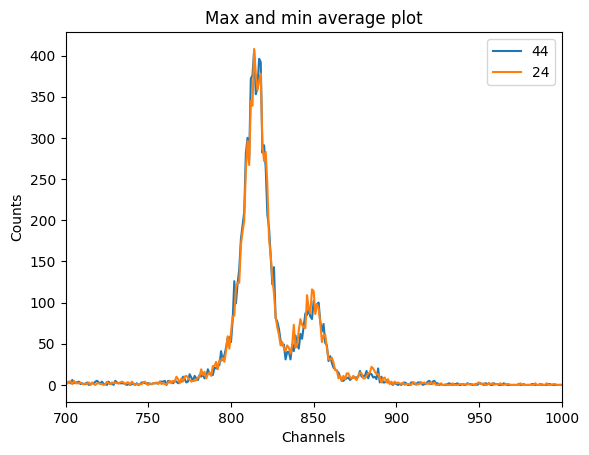

In [65]:
def plotdata(num, obj_name="ADC_HIGH_7",base_path="slitA-004-{:03d}.root"):
    file_name = base_path.format(num)
    index = num-1
    with uproot.open(file_name) as f:
        hist = f[obj_name]
        values = hist.values()
        x_edges = hist.axes[0].edges()

    total_counts = np.sum(values)

    plt.plot(values,label=num)
    plt.xlim(700,1000)
    return values

plotdata(file_numbers[minnum])
plotdata(file_numbers[maxnum])
plt.legend()
plt.xlabel("Channels")
plt.ylabel("Counts")
plt.title("Max and min average plot")

ほぼ、変化が見られない


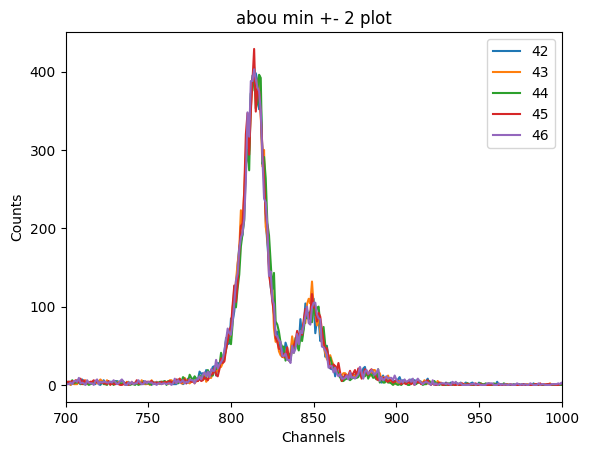

In [68]:
for i in[-2,-1,0,1,2]:
    plotdata(file_numbers[minnum+i])



plt.legend()
plt.xlabel("Channels")
plt.ylabel("Counts")
plt.title("abou min +- 2 plot")
print("ほぼ、変化が見られない")